In [2]:
with open("C:/Users/edier/Documents/CATEDRA/MACHINE LEARNING/datos/raster/dtm.asc") as f:
    lines = f.readlines()

In [4]:
type(lines)

list

In [6]:
import numpy as np

matrix=np.loadtxt("C:/Users/edier/Documents/CATEDRA/MACHINE LEARNING/datos/raster/dtm.asc", skiprows=6)

In [7]:
matrix

array([[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       ...,
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],
      shape=(456, 435))

In [19]:
import rasterio

with rasterio.open("C:/Users/edier/Documents/CATEDRA/MACHINE LEARNING/datos/raster/dtm.asc") as src:
    dtm = src.read(1)
    dtm_mask = src.read(1, masked=True)

In [20]:
dtm_mask

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-9999.0,
  dtype=float32)

In [21]:
dtm_mask.min()

np.float32(1093.078)

In [23]:
dtm.min()

np.float32(-9999.0)

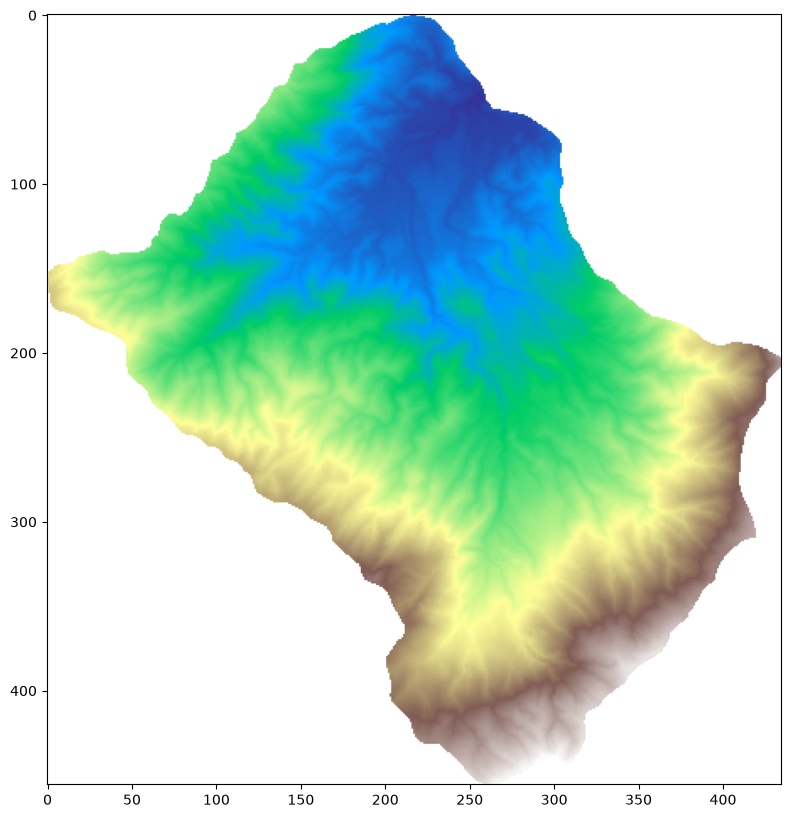

In [28]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(dtm_mask, cmap='terrain')

In [39]:
with rasterio.open("prueba.tif","w",driver="GTiff", dtype="float32", nodata=-9999.0,
              width=435, height=456, count=1, crs=None,
              blockxsize=435, blockysize=1, tiled=False, compress="lzw") as dst:
    dst.write(np.nan_to_num(dtm, nan=-9999.0).astype("float32"), 1)

In [42]:
with rasterio.open(r"C:\Users\edier\Documents\CATEDRA\MACHINE LEARNING\datos\raster\geologia.txt") as src:
    geologia = src.read(1, masked=True)

In [43]:
geologia

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-9999,
  dtype=int32)

In [44]:
codigos, conteos = np.unique(geologia.compressed(), return_counts=True)

In [46]:
import pandas as pd

unidades = pd.DataFrame({
    "codigo": codigos,
    "celdas": conteos,
    "area_ha": conteos * 10 * 10 / 10_000,     # celdas de 10 x 10 m
})

In [47]:
unidades.head()

,codigo,celdas,area_ha
0,18,263124,2631.24
1,19,3245,32.45
2,22,34525,345.25
3,25,6363,63.63
4,27,12969,129.69


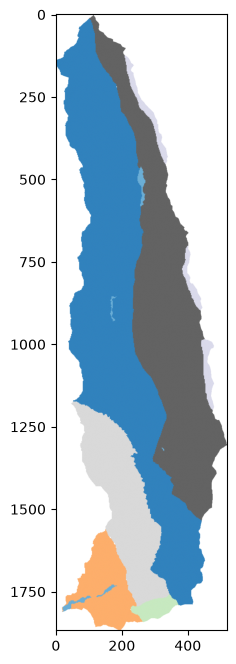

In [48]:
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(geologia, cmap="tab20c")

In [49]:
from rasterio.crs import CRS

crs_magna = CRS.from_epsg(3116)


with rasterio.open("prueba2.tif","w",driver="GTiff", dtype="float32", nodata=-9999.0,
              width=435, height=456, count=1, crs=None,
              blockxsize=435, blockysize=1, tiled=False, compress="lzw") as dst:
    dst.write(dtm, 1)

C:\Users\edier\AppData\Roaming\Python\Python314\site-packages\rasterio\__init__.py:389: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


In [51]:
with rasterio.open(r"C:\Users\edier\Documents\CATEDRA\MACHINE LEARNING\datos\raster\geologia.txt") as src:
    perfil = src.profile.copy()
    geologia = src.read(1)



In [52]:
perfil

{'driver': 'AAIGrid', 'dtype': 'int32', 'nodata': -9999.0, 'width': 519, 'height': 1868, 'count': 1, 'crs': None, 'transform': Affine(10.0, 0.0, 829734.05499953,
       0.0, -10.0, 1154454.0875265), 'blockxsize': 519, 'blockysize': 1, 'tiled': False}

In [60]:
with rasterio.open('prueba.asc', 'w', driver= 'AAIGrid', dtype= 'int32', nodata= -9999.0, width= 519, 
                   height= 1868, count= 1, crs= crs_magna, blockxsize= 519, blockysize= 1, tiled= False) as dst:
    dst.write(dtm, 1)

C:\Users\edier\AppData\Roaming\Python\Python314\site-packages\rasterio\__init__.py:389: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


In [65]:
from urllib.request import urlretrieve
from pathlib import Path


def descargar(url, destino):
    """Descarga la url solo si el archivo no existe ya en el disco."""
    if not destino.exists():
        urlretrieve(url, destino)
    return destino


url_nc = "https://github.com/pydata/xarray-data/raw/master/air_temperature.nc"

ruta_nc = descargar(url_nc, Path("air_temperature.nc"))



In [66]:
import xarray as xr

ds = xr.open_dataset("air_temperature.nc")
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB ...
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [68]:
ds.data_vars

Data variables:
    air      (time, lat, lon) float64 31MB ...

In [72]:
ds["air"].attrs.items()

dict_items([('long_name', '4xDaily Air temperature at sigma level 995'), ('units', 'degK'), ('precision', np.int16(2)), ('GRIB_id', np.int16(11)), ('GRIB_name', 'TMP'), ('var_desc', 'Air temperature'), ('dataset', 'NMC Reanalysis'), ('level_desc', 'Surface'), ('statistic', 'Individual Obs'), ('parent_stat', 'Other'), ('actual_range', array([185.16, 322.1 ], dtype='>f4'))])

In [73]:
media_temporal = ds["air"].mean("time")           # promedio de los dos años, celda a celda
serie_medellin = ds["air"].sel(lat=25, lon=260, method="nearest")   # serie en un punto

In [74]:
media_temporal

<xarray.DataArray 'air' (lat: 25, lon: 53)> Size: 11kB
array([[260.37644178, 260.18305137, 259.88662671, ..., 250.81590068,
        251.93811644, 253.43804795],
       [262.73439384, 262.79397603, 262.74933904, ..., 249.75590411,
        251.58575685, 254.35926027],
       [264.7687637 , 264.32730822, 264.06169521, ..., 250.60789041,
        253.58351027, 257.71559932],
       ...,
       [297.64986301, 296.95333219, 296.62931507, ..., 296.81092466,
        296.28796233, 295.81645548],
       [298.12920205, 297.93700685, 297.47039384, ..., 296.85954795,
        296.7770274 , 296.44383562],
       [298.36615068, 298.38573973, 298.11414384, ..., 297.33820548,
        297.28144521, 297.30510274]], shape=(25, 53))
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

In [75]:
serie_medellin

<xarray.DataArray 'air' (time: 2920)> Size: 23kB
array([295.1 , 292.  , 290.4 , ..., 286.99, 286.99, 286.49], shape=(2920,))
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
    lat      float32 4B 25.0
    lon      float32 4B 260.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

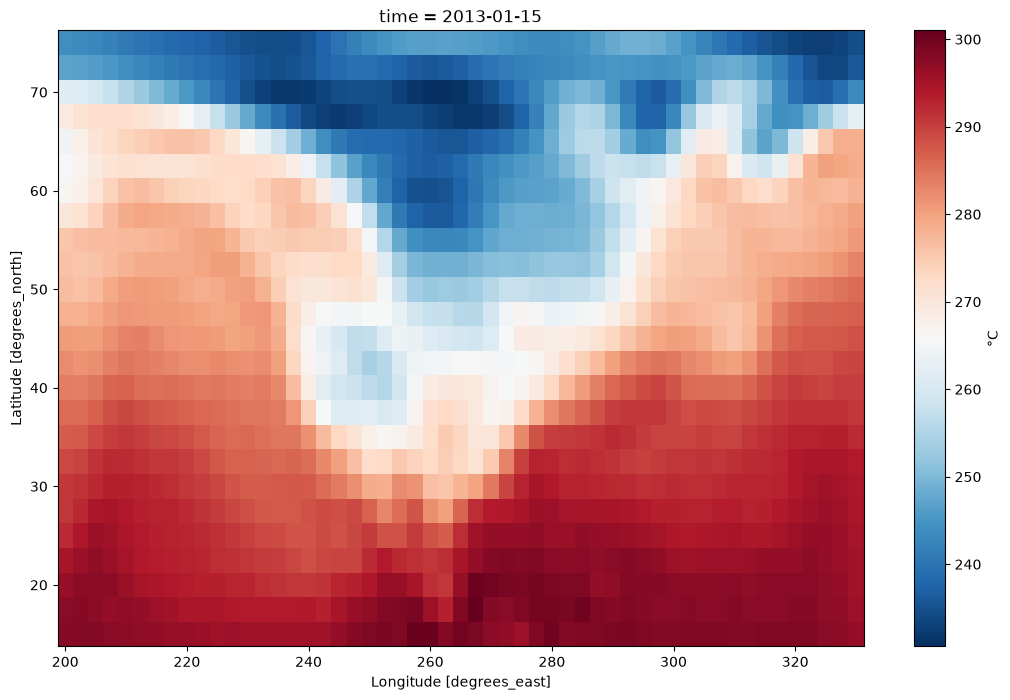

In [78]:
fig, ax = plt.subplots(figsize=(13, 8))

ds["air"].sel(time="2013-01-15T00:00:00").plot(ax=ax, cmap="RdBu_r", cbar_kwargs={"label": "°C"})

In [79]:
media = media_temporal.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
media = media_temporal.rio.write_crs("EPSG:4326")      # las coordenadas son grados geográficos
media.rio.to_raster("air_media_2013_2014.tif")